<a href="https://colab.research.google.com/github/hania-sajjad/WEEK-3-TASK/blob/main/notebooks%20/week3_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

import joblib

In [3]:
# UPLOAD AND LOAD DATA
from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/Week2Data/steel_energy_engineered.csv"

df = pd.read_csv(file_path)

df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Day_Name,Month,Day_Type,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,Monday,1,Weekday,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,Monday,1,Weekday,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,Monday,1,Weekday,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,Monday,1,Weekday,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,Monday,1,Weekday,1.545117,0


In [4]:
print(df.shape)
df.info()

(35040, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
 11  Hou

In [5]:
X = df.drop(["Usage_kWh", "date"], axis=1)
y = df["Usage_kWh"]

# One-hot encoding (same as Week 2)
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(35040, 26)


**Note:** The original `date` column was removed before modeling because its useful temporal information had already been extracted into engineered features such as `Hour`, `Month`, `Day_Name`, and `Day_Type`. Keeping the raw timestamp would create thousands of unnecessary dummy variables during one-hot encoding and increase memory usage without improving model performance.

## Train-Test Split, Standard Scaling, and PCA Preparation

To prevent data leakage, the dataset is first split into training and testing sets using the same train-test split as Week 2. Since PCA is sensitive to the scale of features, the data is standardized using `StandardScaler`. The scaler is fitted only on the training data and then applied to both the training and testing sets. This ensures that information from the test set is not used during training.

In [6]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardize the features
scaler = StandardScaler()

# Fit the scaler on the training data and transform both datasets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display the shapes of the scaled datasets
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (28032, 26)
Testing data shape: (7008, 26)


## Apply PCA with All Principal Components

Principal Component Analysis (PCA) is applied using the total number of input features as the number of principal components. This allows us to examine the explained variance of every component and determine how much information each one retains. The PCA model is fitted only on the scaled training data and then used to transform both the training and testing sets.

In [7]:
# Apply PCA using all available features
n_features = X_train_scaled.shape[1]

pca = PCA(n_components=n_features)

# Fit PCA on the training data and transform both datasets
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Store the explained variance ratio of each principal component
explained_variance = pca.explained_variance_ratio_

# Display the explained variance ratio
explained_variance

array([2.09116575e-01, 1.63024295e-01, 1.02480220e-01, 8.99747585e-02,
       8.97688123e-02, 8.96007065e-02, 8.65133948e-02, 4.42844074e-02,
       4.04865083e-02, 3.49961249e-02, 1.54927572e-02, 1.45800217e-02,
       8.94775778e-03, 6.45935162e-03, 2.53779898e-03, 1.52191047e-03,
       1.83247432e-04, 3.13522660e-05, 1.63625247e-17, 1.01378384e-17,
       9.80083644e-18, 7.61847318e-18, 4.53710389e-18, 9.53970618e-19,
       0.00000000e+00, 0.00000000e+00])

## Scree Plot

A scree plot is created to visualize the explained variance ratio of each principal component. It helps identify how much information is retained by each component and whether a smaller number of components can effectively represent the original dataset.

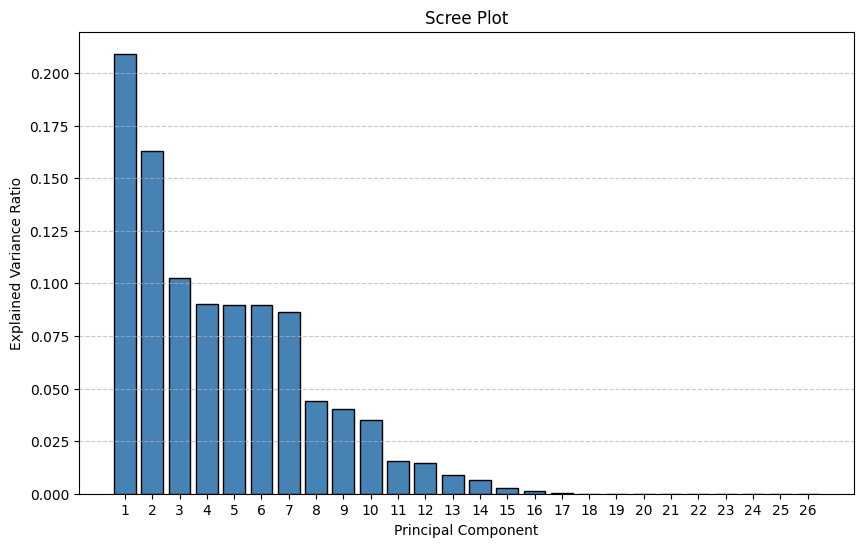

In [8]:
# Create a scree plot showing the explained variance ratio of each principal component

plt.figure(figsize=(10, 6))

plt.bar(
    range(1, len(explained_variance) + 1),
    explained_variance,
    color='steelblue',
    edgecolor='black'
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Observation

The scree plot shows that the first few principal components explain a large proportion of the total variance, while the remaining components contribute progressively less. This suggests that the dimensionality of the dataset may be reduced without losing a significant amount of information.